# COMP 9130 — Cascade R-CNN on DAWN Dataset
**Group:** TeamFoggyVision | **Model:** Cascade R-CNN (Detectron2)

This notebook covers the full pipeline for Member 1:
- Dataset preparation and EDA
- DAWN dataset conversion to COCO format
- Cascade R-CNN fine-tuning with Detectron2
- Evaluation (precision, recall, mAP@0.5, mAP@0.5-0.95, FPS)
- Comparison against Faster R-CNN baseline
- Results by weather condition

## 1. Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [3]:
# Install Detectron2 (Colab / Linux with CUDA 11.8)
import sys

# Detectron2 wheel — pick the right one for your CUDA version
# For CUDA 11.8 + PyTorch 2.x:
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

# Other dependencies
!pip install -q kaggle pycocotools opencv-python matplotlib seaborn pandas tqdm torch torchvision

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 33.0 MB/s eta 0:00:00


In [66]:
import os, json, random, time, copy, shutil
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.notebook import tqdm

import detectron2
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.logger import setup_logger

setup_logger()
print("Detectron2 version:", detectron2.__version__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_DIR = Path("./dawn_dataset")
COCO_DIR = Path("./dawn_coco")
OUTPUT_DIR = Path("./output_cascade_rcnn")
OUTPUT_DIR.mkdir(exist_ok=True)

Detectron2 version: 0.6


## 2. Download DAWN Dataset from Kaggle

In [5]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [6]:
#download data
os.makedirs("./data", exist_ok=True)
os.environ['DISABLE_COLAB_CACHE'] = "true"

path = kagglehub.dataset_download("shuvoalok/dawn-dataset", output_dir="./data")

print("data/", path)

100%|██████████| 132M/132M [00:01<00:00, 114MB/s]

Extracting files...


data/ ./data


In [7]:
WEATHER_CONDITIONS = ["fog", "rain", "snow", "sand"]
output_dir = "./data/filtered"
for cond in WEATHER_CONDITIONS:
    os.makedirs(os.path.join(output_dir, cond), exist_ok=True)

def _filter(input_dir, out):
    for filename in os.listdir(input_dir):
        if not filename.endswith(".jpg"):
            continue
        name = filename.lower()
        if "snow" in name:
            dest = os.path.join(out, "snow", filename)
        elif "rain" in name or "mist" in name:
            dest = os.path.join(out, "rain", filename)
        elif "fog" in name or "haze" in name:
            dest = os.path.join(out, "fog", filename)
        elif "sand" in name or "dust" in name:
            dest = os.path.join(out, "sand", filename)
        else:
            continue
        shutil.copy(os.path.join(input_dir, filename), dest)

_filter("./data/images", output_dir)

In [ ]:
#filter labels


## 3. Dataset Exploration (EDA)

In [69]:
# ── Adjust these paths to match the actual DAWN folder layout ──────────────
# DAWN typically has per-weather folders: Fog/, Rain/, Sand/, Snow/
# Each folder has images/ and annotations/ (Pascal VOC XML or COCO JSON)

WEATHER_CONDITIONS = ["Fog", "Rain", "Sand", "Snow"]

# Collect all image paths and check annotation format
def discover_dataset(root: Path):
    records = []
    for weather in WEATHER_CONDITIONS:
        img_dir = root / weather
        if not img_dir.exists():
            # Try lowercase
            img_dir = root / weather.lower()
        for img_path in img_dir.rglob("*.jpg"):
            records.append({"path": str(img_path), "weather": weather})
        for img_path in img_dir.rglob("*.png"):
            records.append({"path": str(img_path), "weather": weather})
    return pd.DataFrame(records)

# Point to actual dataset root — update if needed
DAWN_ROOT = Path("./data/filtered")  # update to actual path after unzip
df_images = discover_dataset(DAWN_ROOT)
print(f"Total images found: {len(df_images)}")
#print(df_images["weather"].value_counts())

Total images found: 1027


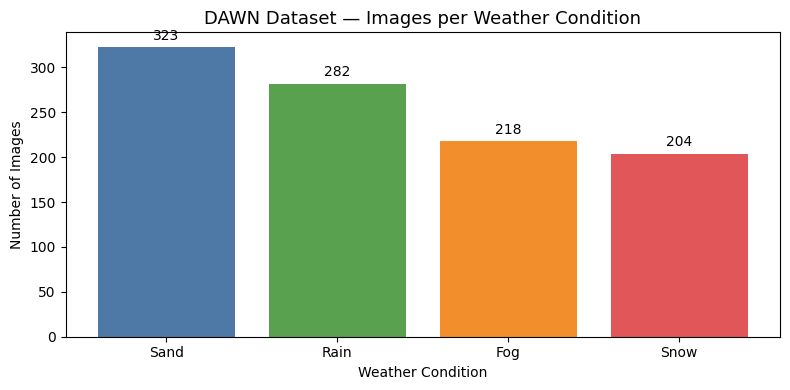

In [70]:
# Plot image distribution per weather condition
fig, ax = plt.subplots(figsize=(8, 4))
counts = df_images["weather"].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=["#4e79a7", "#59a14f", "#f28e2b", "#e15759"])
ax.bar_label(bars, padding=3)
ax.set_title("DAWN Dataset — Images per Weather Condition", fontsize=13)
ax.set_ylabel("Number of Images")
ax.set_xlabel("Weather Condition")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_weather_distribution.png", dpi=150)
plt.show()

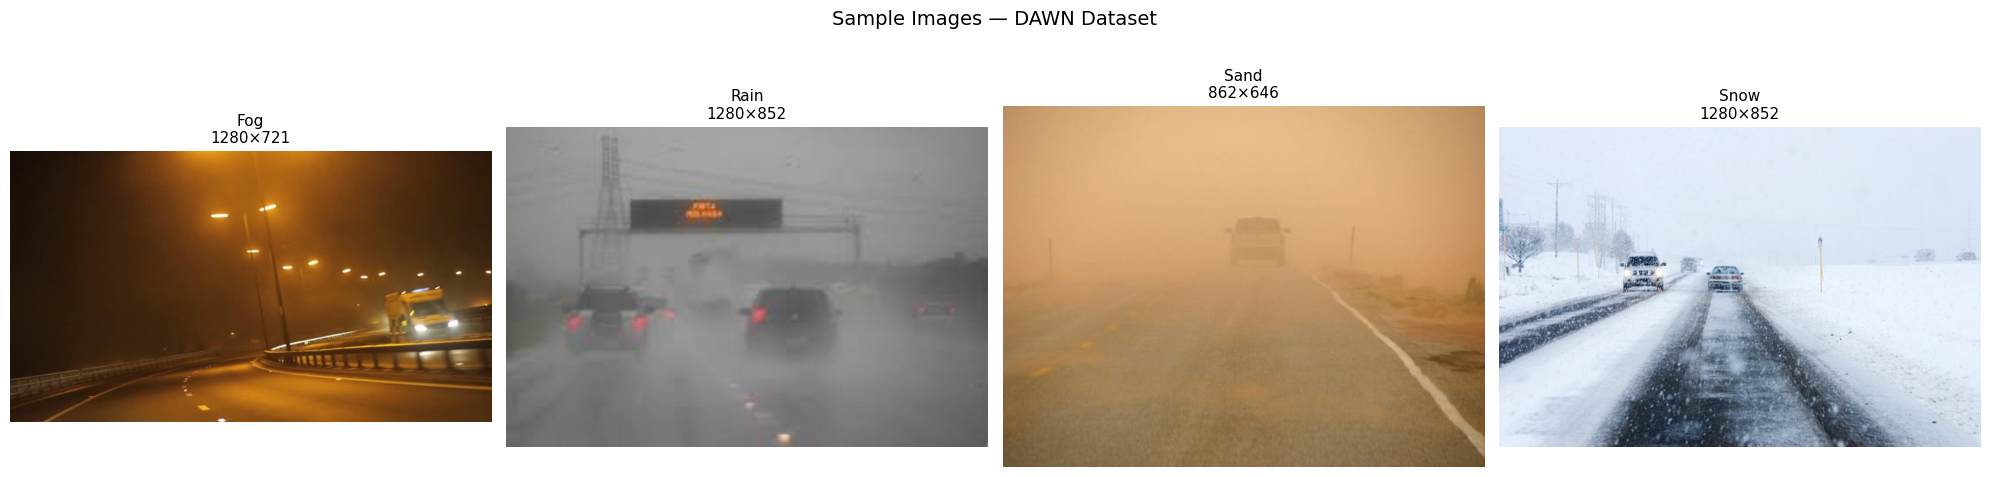

In [71]:
# Sample images from each condition
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, weather in zip(axes, WEATHER_CONDITIONS):
    subset = df_images[df_images["weather"] == weather]
    if len(subset) == 0:
        ax.set_title(f"{weather}\n(not found)")
        ax.axis("off")
        continue
    img_path = subset.sample(1)["path"].values[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{weather}\n{img.shape[1]}×{img.shape[0]}", fontsize=11)
    ax.axis("off")
plt.suptitle("Sample Images — DAWN Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Convert DAWN Annotations to COCO Format

DAWN ships with Pascal VOC XML annotations. This section converts them to COCO JSON and creates the 80/10/10 train/val/test split.

In [72]:
LABELS_DIR = Path("data/labels")   # adjust to your labels folder

# old_id -> new_id
REMAP = {
    8: 0,   # Truck
    1: 1,   # Person
    2: 2,   # Bicycle
    3: 3,   # Car
    4: 4,   # Motorcycle
    6: 5,   # Bus
}

NEW_CLASSES = ["Truck", "Person", "Bicycle", "Car", "Motorcycle", "Bus"]

n_files, n_boxes, n_dropped = 0, 0, 0

for txt in LABELS_DIR.rglob("*.txt"):
    new_lines = []
    for line in txt.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        old_id = int(parts[0])
        if old_id not in REMAP:
            n_dropped += 1            # class not in target set -> skip
            continue
        parts[0] = str(REMAP[old_id])
        new_lines.append(" ".join(parts))
        n_boxes += 1
    txt.write_text("\n".join(new_lines) + ("\n" if new_lines else ""))
    n_files += 1

print(f"Rewrote {n_files} files | kept {n_boxes} boxes | dropped {n_dropped}")
print("New class order:", NEW_CLASSES)


Rewrote 1027 files | kept 7038 boxes | dropped 0
New class order: ['Truck', 'Person', 'Bicycle', 'Car', 'Motorcycle', 'Bus']


In [73]:
# ── New Section 4: Split & Register with Detectron2 ─────────────────────────
from sklearn.model_selection import train_test_split
from detectron2.structures import BoxMode

# Define the classes present in the DAWN dataset (assuming 7 classes as per model config)
# YOLO_CLASSES = ["car", "truck", "bus", "motorcycle", "bicycle", "pedestrian", "traffic_light"]
# YOLO_CLASSES = ["bicycle", "boat", "bus", "car", "motorcycle",
#                 "person", "traffic_light", "truck", "traffic_sign"]
YOLO_CLASSES = ["truck", "person", "bicycle", "car", "motorcycle", "bus"]
# Convert df_images to a list of dicts so we can pass it to train_test_split
# Each record is: {"path": "...", "weather": "Fog"} etc.
records = df_images.to_dict("records")

# Stratified 80/10/10 split — stratify ensures each weather condition
# is proportionally represented in train, val, and test
train_recs, temp_recs = train_test_split(
    records, test_size=0.20, random_state=SEED,
    stratify=[r["weather"] for r in records]
)
# Split the remaining 20% evenly into val and test (10% each)
val_recs, test_recs = train_test_split(
    temp_recs, test_size=0.50, random_state=SEED,
    stratify=[r["weather"] for r in temp_recs]
)
print(f"Train: {len(train_recs)} | Val: {len(val_recs)} | Test: {len(test_recs)}")


def get_dawn_dicts(records: list):
    """
    Convert a list of image records into Detectron2 dataset dicts.
    Reads YOLO .txt annotation files and converts normalised coordinates
    to absolute pixel coordinates that Detectron2 expects.
    """
    dataset_dicts = []

    for img_id, row in enumerate(records):
        img_path = Path(row["path"])

        # Look for the .txt label file next to the image first,
        # then fall back to a sibling labels/ folder (common YOLO layout)
        txt_path = img_path.with_suffix(".txt")
        if not txt_path.exists():
            #txt_path = img_path.parent.parent / "labels" / img_path.with_suffix(".txt").name
            txt_path = img_path.parent.parent.parent / "labels" / img_path.with_suffix(".txt").name

        # Skip this image entirely if no annotation file is found
        if not txt_path.exists():
            continue

        # Read the image to get its actual pixel dimensions —
        # needed to convert YOLO's normalised coords back to pixels
        img_cv = cv2.imread(str(img_path))
        if img_cv is None:
            continue
        h, w = img_cv.shape[:2]

        annotations = []
        for line in txt_path.read_text().strip().splitlines():
            parts = line.split()

            # Each valid YOLO line has exactly 5 values:
            # class_id  x_center  y_center  width  height
            if len(parts) != 5:
                continue

            cls_id = int(parts[0])

             # Validate class_id against the number of defined classes
            if not (0 <= cls_id < len(YOLO_CLASSES)): # YOLO_CLASSES has 7 entries, so valid IDs are 0-6
                # Optionally log a warning here
                print(f"Warning: Skipping annotation with invalid class_id={cls_id} in {txt_path}")
                continue  # Skip this specific annotation if its class_id is invalid
            xc, yc, bw, bh = map(float, parts[1:])

            # Convert from normalised xywh → absolute xyxy pixel coords
            # YOLO stores box centre + size, Detectron2 wants top-left + bottom-right
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h

            annotations.append({
                "bbox": [x1, y1, x2, y2],
                # Tell Detectron2 the bbox is in absolute pixel coords (not normalised)
                "bbox_mode": BoxMode.XYXY_ABS,
                # class_id maps directly to YOLO_CLASSES list index
                "category_id": cls_id,
            })

        # Skip images that have a label file but no valid annotation lines
        if not annotations:
            continue

        dataset_dicts.append({
            "file_name": str(img_path),
            "image_id": img_id,
            "height": h,
            "width": w,
            "annotations": annotations,
            # Store weather tag so we can filter by condition later in Section 10
            "weather": row["weather"],
        })

    return dataset_dicts


# Register all three splits in Detectron2's DatasetCatalog.
# We use a lambda with a default argument (r=split_recs) to capture
# the current value of split_recs — without this, all three lambdas
# would reference the same variable and end up pointing at test_recs.
for split_name, split_recs in [("train", train_recs), ("val", val_recs), ("test", test_recs)]:
    name = f"dawn_{split_name}"

    # Remove existing registration if re-running this cell
    if name in DatasetCatalog:
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

    DatasetCatalog.register(name, lambda r=split_recs: get_dawn_dicts(r))

    # Attach class names so Detectron2 visualisers can label boxes correctly
    MetadataCatalog.get(name).set(thing_classes=YOLO_CLASSES)

METADATA = MetadataCatalog.get("dawn_train")
print("Registered: dawn_train, dawn_val, dawn_test")
print("Classes:", METADATA.thing_classes)

Train: 821 | Val: 103 | Test: 103
Registered: dawn_train, dawn_val, dawn_test
Classes: ['truck', 'person', 'bicycle', 'car', 'motorcycle', 'bus']


## 6. Configure Cascade R-CNN

In [74]:
def build_cascade_rcnn_cfg(train_dataset="dawn_train",
                            val_dataset="dawn_val",
                            output_dir=str(OUTPUT_DIR),
                            epochs=None,
                            max_iter=5000,
                            base_lr=0.001,
                            batch_size=2,
                            num_classes=len(YOLO_CLASSES)): # Changed DAWN_CLASSES to YOLO_CLASSES
    cfg = get_cfg()

    # Cascade R-CNN with ResNet-50 FPN backbone pretrained on COCO
    cfg.merge_from_file(
        model_zoo.get_config_file(
            "Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"
        )
    )
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
        "Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"
    )

    # Disable the mask head if only object detection is needed
    cfg.MODEL.MASK_ON = False

    # Dataset
    cfg.DATASETS.TRAIN = (train_dataset,)
    cfg.DATASETS.TEST = (val_dataset,)

    # Dataloader
    cfg.DATALOADER.NUM_WORKERS = 2

    # --- Epochs -> iterations conversion ---
    num_train_images = len(DatasetCatalog.get(train_dataset))
    iters_per_epoch = max(1, num_train_images // batch_size)

    if epochs is not None:
        max_iter = epochs * iters_per_epoch
        print(f"[epochs mode] {num_train_images} imgs / batch {batch_size} "
              f"= {iters_per_epoch} iters/epoch × {epochs} epochs = {max_iter} iters")
    else:
        # derive effective epochs for logging
        epochs = max_iter / iters_per_epoch
        print(f"[iter mode] {max_iter} iters ≈ {epochs:.2f} epochs "
              f"({iters_per_epoch} iters/epoch)")

    # Solver
    cfg.SOLVER.IMS_PER_BATCH = batch_size
    cfg.SOLVER.BASE_LR = base_lr
    cfg.SOLVER.MAX_ITER = max_iter
    cfg.SOLVER.STEPS = (int(max_iter * 0.7), int(max_iter * 0.9))  # LR decay steps
    cfg.SOLVER.GAMMA = 0.1
    cfg.SOLVER.WARMUP_ITERS = 500
    cfg.SOLVER.CHECKPOINT_PERIOD = max_iter

    # Model
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = num_classes
    cfg.MODEL.BACKBONE.FREEZE_AT = 3
    # Cascade R-CNN has 3 stages — each needs num_classes set
    cfg.MODEL.ROI_BOX_CASCADE_HEAD.IOUS = (0.5, 0.6, 0.7)  # cascade IoU thresholds

    # Input
    cfg.INPUT.MIN_SIZE_TRAIN = (640, 800)
    cfg.INPUT.MIN_SIZE_TEST = 800

    # Eval period
    # cfg.TEST.EVAL_PERIOD = max(500, max_iter // 5)
    cfg.TEST.EVAL_PERIOD = 500

    cfg.OUTPUT_DIR = output_dir
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    return cfg


cfg = build_cascade_rcnn_cfg(epochs=20, base_lr=0.00025, batch_size=2)
print("Config ready.")
print(f"  Backbone: ResNet-50 FPN")
print(f"  Max iterations: {cfg.SOLVER.MAX_ITER}")
print(f"  Base LR: {cfg.SOLVER.BASE_LR}")
print(f"  Batch size: {cfg.SOLVER.IMS_PER_BATCH}")
print(f"  Num classes: {cfg.MODEL.ROI_HEADS.NUM_CLASSES}")

[epochs mode] 810 imgs / batch 2 = 405 iters/epoch × 20 epochs = 8100 iters
Config ready.
  Backbone: ResNet-50 FPN
  Max iterations: 8100
  Base LR: 0.00025
  Batch size: 2
  Num classes: 6


## 7. Training

In [75]:
class DAWNTrainer(DefaultTrainer):
    """Custom trainer that adds COCO evaluation on the validation set."""

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, output_dir=output_folder)


# ── FULL DATASET TRAINING ───────────────────────────────────────────────────
print("Starting Cascade R-CNN training on full DAWN training set...")
print("This will take ~30-60 min on a T4 GPU.")

trainer = DAWNTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

Starting Cascade R-CNN training on full DAWN training set...
This will take ~30-60 min on a T4 GPU.
[04/15 02:16:37 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bia

roi_heads.box_predictor.0.cls_score.{bias, weight}
roi_heads.box_predictor.1.cls_score.{bias, weight}
roi_heads.box_predictor.2.cls_score.{bias, weight}
  roi_heads.mask_head.mask_fcn1.{bias, weight}
  roi_heads.mask_head.mask_fcn2.{bias, weight}
  roi_heads.mask_head.mask_fcn3.{bias, weight}
  roi_heads.mask_head.mask_fcn4.{bias, weight}
  roi_heads.mask_head.deconv.{bias, weight}
  roi_heads.mask_head.predictor.{bias, weight}


[04/15 02:16:42 d2.engine.train_loop]: Starting training from iteration 0
[04/15 02:16:45 d2.utils.events]:  eta: 0:17:15  iter: 19  total_loss: 7.108  loss_cls_stage0: 1.823  loss_box_reg_stage0: 0.2644  loss_cls_stage1: 1.915  loss_box_reg_stage1: 0.5454  loss_cls_stage2: 1.871  loss_box_reg_stage2: 0.639  loss_rpn_cls: 0.02327  loss_rpn_loc: 0.02366    time: 0.1259  last_time: 0.1324  data_time: 0.0122  last_data_time: 0.0050   lr: 9.7405e-06  max_mem: 8537M
[04/15 02:16:47 d2.utils.events]:  eta: 0:17:07  iter: 39  total_loss: 6.625  loss_cls_stage0: 1.702  loss_box_reg_stage0: 0.257  loss_cls_stage1: 1.795  loss_box_reg_stage1: 0.5195  loss_cls_stage2: 1.748  loss_box_reg_stage2: 0.5273  loss_rpn_cls: 0.03157  loss_rpn_loc: 0.02205    time: 0.1248  last_time: 0.1139  data_time: 0.0050  last_data_time: 0.0049   lr: 1.9731e-05  max_mem: 8537M
[04/15 02:16:50 d2.utils.events]:  eta: 0:17:05  iter: 59  total_loss: 5.739  loss_cls_stage0: 1.403  loss_box_reg_stage0: 0.2339  loss_cls_st

## 8. Data Fraction Experiments (25%, 50%, 75%)

Per the project plan, we test how quickly the model converges when fine-tuned on fractions of the DAWN dataset.

In [76]:
import math
def create_fraction_dataset(fraction: float, train_records: list) -> str:
    """Register a random sub-sample of the training records."""
    n = max(1, int(len(train_records) * fraction))
    subset = random.sample(train_records, n)
    name = f"dawn_train_frac{int(fraction * 100)}"

    if name in DatasetCatalog:
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

    DatasetCatalog.register(name, lambda s=subset: get_dawn_dicts(s))
    MetadataCatalog.get(name).set(thing_classes=YOLO_CLASSES)

    print(f"Registered {name}: {len(subset)} images ({fraction*100:.0f}% of {len(train_records)})")
    return name


EPOCHS = 20
IMS_PER_BATCH = 2

fraction_results = {}

for frac in [0.25, 0.50, 0.75]:
    frac_pct = int(frac * 100)
    print(f"\n{'='*60}")
    print(f"Training on {frac_pct}% of DAWN training data...")
    print(f"{'='*60}")

    frac_ds = create_fraction_dataset(frac, train_recs)
    frac_out = OUTPUT_DIR / f"frac{frac_pct}"
    frac_out.mkdir(exist_ok=True)

    n_imgs = len(DatasetCatalog.get(frac_ds))
    iters_per_epoch = math.ceil(n_imgs / IMS_PER_BATCH)
    frac_iters = EPOCHS * iters_per_epoch

    # frac_iters = max(1000, int(5000 * frac))
    cfg_frac = build_cascade_rcnn_cfg(
        train_dataset=frac_ds,
        val_dataset="dawn_test",
        output_dir=str(frac_out),
        max_iter=frac_iters,
    )



    t0 = time.time()
    trainer_frac = DAWNTrainer(cfg_frac)
    trainer_frac.resume_or_load(resume=False)
    trainer_frac.train()
    elapsed = time.time() - t0

    cfg_frac.MODEL.WEIGHTS = str(frac_out / "model_final.pth")
    # cfg_frac.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # optional, match your full-data run


    predictor_frac = DefaultPredictor(cfg_frac)
    evaluator = COCOEvaluator("dawn_test", output_dir=str(frac_out / "eval_test"))
    loader = build_detection_test_loader(cfg_frac, "dawn_test")
    results = inference_on_dataset(predictor_frac.model, loader, evaluator)

    # fraction_results[frac_pct] = {
    #     "map50": results["bbox"]["AP50"],
    #     "map": results["bbox"]["AP"],
    #     "training_time_min": elapsed / 60,
    #     "iterations": frac_iters,
    # }
    frac_eval = results
    fraction_results[frac_pct] = {
      "map50": frac_eval["bbox"]["AP50"],
      "map":   frac_eval["bbox"]["AP"],
      "precision": frac_eval["bbox"].get("AP",  None),   # COCO AP ≈ precision proxy
      "recall":    frac_eval["bbox"].get("AR",  None),
      # "fps":       frac_fps,   # time the inference loop like you did for 100%
    }

    print(f"\nFrac {frac_pct}% → mAP50: {results['bbox']['AP50']:.2f} | mAP: {results['bbox']['AP']:.2f} | Time: {elapsed/60:.1f} min")

print("\nFraction experiment complete.")


Training on 25% of DAWN training data...
Registered dawn_train_frac25: 205 images (25% of 821)
[iter mode] 2040 iters ≈ 20.00 epochs (102 iters/epoch)
[04/15 02:35:32 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, ke

roi_heads.box_predictor.0.cls_score.{bias, weight}
roi_heads.box_predictor.1.cls_score.{bias, weight}
roi_heads.box_predictor.2.cls_score.{bias, weight}
  roi_heads.mask_head.mask_fcn1.{bias, weight}
  roi_heads.mask_head.mask_fcn2.{bias, weight}
  roi_heads.mask_head.mask_fcn3.{bias, weight}
  roi_heads.mask_head.mask_fcn4.{bias, weight}
  roi_heads.mask_head.deconv.{bias, weight}
  roi_heads.mask_head.predictor.{bias, weight}


[04/15 02:35:33 d2.engine.train_loop]: Starting training from iteration 0
[04/15 02:35:36 d2.utils.events]:  eta: 0:04:17  iter: 19  total_loss: 6.789  loss_cls_stage0: 1.96  loss_box_reg_stage0: 0.1903  loss_cls_stage1: 1.845  loss_box_reg_stage1: 0.4019  loss_cls_stage2: 1.865  loss_box_reg_stage2: 0.4909  loss_rpn_cls: 0.02004  loss_rpn_loc: 0.01633    time: 0.1278  last_time: 0.1318  data_time: 0.0148  last_data_time: 0.0049   lr: 3.8962e-05  max_mem: 8542M
[04/15 02:35:39 d2.utils.events]:  eta: 0:04:14  iter: 39  total_loss: 5.711  loss_cls_stage0: 1.458  loss_box_reg_stage0: 0.2706  loss_cls_stage1: 1.427  loss_box_reg_stage1: 0.5264  loss_cls_stage2: 1.384  loss_box_reg_stage2: 0.5898  loss_rpn_cls: 0.03125  loss_rpn_loc: 0.02101    time: 0.1267  last_time: 0.1237  data_time: 0.0047  last_data_time: 0.0050   lr: 7.8922e-05  max_mem: 8542M
[04/15 02:35:41 d2.utils.events]:  eta: 0:04:14  iter: 59  total_loss: 3.206  loss_cls_stage0: 0.7073  loss_box_reg_stage0: 0.1932  loss_cls_

roi_heads.box_predictor.0.cls_score.{bias, weight}
roi_heads.box_predictor.1.cls_score.{bias, weight}
roi_heads.box_predictor.2.cls_score.{bias, weight}
  roi_heads.mask_head.mask_fcn1.{bias, weight}
  roi_heads.mask_head.mask_fcn2.{bias, weight}
  roi_heads.mask_head.mask_fcn3.{bias, weight}
  roi_heads.mask_head.mask_fcn4.{bias, weight}
  roi_heads.mask_head.deconv.{bias, weight}
  roi_heads.mask_head.predictor.{bias, weight}


[04/15 02:40:40 d2.engine.train_loop]: Starting training from iteration 0
[04/15 02:40:43 d2.utils.events]:  eta: 0:08:45  iter: 19  total_loss: 7.022  loss_cls_stage0: 1.936  loss_box_reg_stage0: 0.2057  loss_cls_stage1: 1.86  loss_box_reg_stage1: 0.4176  loss_cls_stage2: 2.007  loss_box_reg_stage2: 0.5711  loss_rpn_cls: 0.01939  loss_rpn_loc: 0.01968    time: 0.1291  last_time: 0.1298  data_time: 0.0133  last_data_time: 0.0048   lr: 3.8962e-05  max_mem: 8542M
[04/15 02:40:45 d2.utils.events]:  eta: 0:08:40  iter: 39  total_loss: 5.916  loss_cls_stage0: 1.467  loss_box_reg_stage0: 0.2336  loss_cls_stage1: 1.439  loss_box_reg_stage1: 0.4813  loss_cls_stage2: 1.519  loss_box_reg_stage2: 0.4823  loss_rpn_cls: 0.03222  loss_rpn_loc: 0.01992    time: 0.1270  last_time: 0.1285  data_time: 0.0046  last_data_time: 0.0047   lr: 7.8922e-05  max_mem: 8542M
[04/15 02:40:48 d2.utils.events]:  eta: 0:08:37  iter: 59  total_loss: 3.873  loss_cls_stage0: 0.775  loss_box_reg_stage0: 0.214  loss_cls_st

roi_heads.box_predictor.0.cls_score.{bias, weight}
roi_heads.box_predictor.1.cls_score.{bias, weight}
roi_heads.box_predictor.2.cls_score.{bias, weight}
  roi_heads.mask_head.mask_fcn1.{bias, weight}
  roi_heads.mask_head.mask_fcn2.{bias, weight}
  roi_heads.mask_head.mask_fcn3.{bias, weight}
  roi_heads.mask_head.mask_fcn4.{bias, weight}
  roi_heads.mask_head.deconv.{bias, weight}
  roi_heads.mask_head.predictor.{bias, weight}


[04/15 02:50:26 d2.engine.train_loop]: Starting training from iteration 0
[04/15 02:50:29 d2.utils.events]:  eta: 0:13:06  iter: 19  total_loss: 7.409  loss_cls_stage0: 1.847  loss_box_reg_stage0: 0.2916  loss_cls_stage1: 1.876  loss_box_reg_stage1: 0.6195  loss_cls_stage2: 2.02  loss_box_reg_stage2: 0.7274  loss_rpn_cls: 0.05275  loss_rpn_loc: 0.03131    time: 0.1288  last_time: 0.1319  data_time: 0.0133  last_data_time: 0.0048   lr: 3.8962e-05  max_mem: 8542M
[04/15 02:50:31 d2.utils.events]:  eta: 0:12:55  iter: 39  total_loss: 5.668  loss_cls_stage0: 1.389  loss_box_reg_stage0: 0.1881  loss_cls_stage1: 1.448  loss_box_reg_stage1: 0.4258  loss_cls_stage2: 1.566  loss_box_reg_stage2: 0.5122  loss_rpn_cls: 0.02698  loss_rpn_loc: 0.01462    time: 0.1272  last_time: 0.1254  data_time: 0.0049  last_data_time: 0.0048   lr: 7.8922e-05  max_mem: 8542M
[04/15 02:50:34 d2.utils.events]:  eta: 0:12:52  iter: 59  total_loss: 3.866  loss_cls_stage0: 0.7424  loss_box_reg_stage0: 0.2654  loss_cls_

## 9. Evaluation on Validation & Test Sets

In [77]:
# Load best checkpoint from full training
cfg.MODEL.WEIGHTS = str(OUTPUT_DIR / "model_final.pth")
# cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.5

predictor = DefaultPredictor(cfg)

print("Evaluating on validation set...")
val_evaluator = COCOEvaluator("dawn_val", output_dir=str(OUTPUT_DIR / "eval_val"))
val_loader = build_detection_test_loader(cfg, "dawn_val")
val_results = inference_on_dataset(predictor.model, val_loader, val_evaluator)

print("\nEvaluating on test set...")
test_evaluator = COCOEvaluator("dawn_test", output_dir=str(OUTPUT_DIR / "eval_test"))
test_loader = build_detection_test_loader(cfg, "dawn_test")
test_results = inference_on_dataset(predictor.model, test_loader, test_evaluator)

print("\n=== Validation Results ===")
print(val_results)
print("\n=== Test Results ===")
print(test_results)

[04/15 03:06:27 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from output_cascade_rcnn/model_final.pth ...
Evaluating on validation set...
[04/15 03:06:28 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[04/15 03:06:28 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[04/15 03:06:28 d2.data.common]: Serializing 101 elements to byte tensors and concatenating them all ...
[04/15 03:06:28 d2.data.common]: Serialized dataset takes 0.05 MiB
[04/15 03:06:28 d2.evaluation.evaluator]: Start inference on 101 batches
[04/15 03:06:28 d2.evaluation.evaluator]: Inference done 11/101. Dataloading: 0.0012 s/iter. Inference: 0.0393 s/iter. Eval: 0.0003 s/iter. Total: 0.0408 s/iter. ETA=0:00:03
[04/15 03:06:32 d2.evaluation.evaluator]: Total inference time: 0:00:03.843015 (0.040031 s / iter per device, on 1 devices

In [78]:
# Measure inference speed (FPS) on test set
print("Measuring FPS...")
test_dict = DatasetCatalog.get("dawn_test")
N_FPS = min(100, len(test_dict))
fps_sample = random.sample(test_dict, N_FPS)

predictor.model.eval()
times = []
with torch.no_grad():
    for d in tqdm(fps_sample, desc="FPS benchmark"):
        img = cv2.imread(d["file_name"])
        t0 = time.perf_counter()
        _ = predictor(img)
        times.append(time.perf_counter() - t0)

fps = 1.0 / np.mean(times)
lat_ms = np.mean(times) * 1000
print(f"\nCascade R-CNN inference:")
print(f"  Mean latency: {lat_ms:.1f} ms/image")
print(f"  FPS: {fps:.1f}")

Measuring FPS...


FPS benchmark:   0%|          | 0/100 [00:00<?, ?it/s]


Cascade R-CNN inference:
  Mean latency: 61.3 ms/image
  FPS: 16.3


## 10. Results by Weather Condition

In [79]:
# Run evaluation per weather condition
weather_results = {}

for weather in WEATHER_CONDITIONS:
    # Create a test subset for this weather condition
    weather_recs = [r for r in test_recs if r["weather"] == weather]
    if not weather_recs:
        print(f"No test images for {weather}")
        continue

    ds_name = f"dawn_test_{weather.lower()}"

    # Remove existing registration if re-running this cell
    if ds_name in DatasetCatalog:
        DatasetCatalog.remove(ds_name)
        MetadataCatalog.remove(ds_name)

    # Register the dataset directly using get_dawn_dicts
    DatasetCatalog.register(ds_name, lambda w=weather_recs: get_dawn_dicts(w))
    # Attach class names
    MetadataCatalog.get(ds_name).set(thing_classes=YOLO_CLASSES)

    evaluator = COCOEvaluator(ds_name, output_dir=str(OUTPUT_DIR / f"eval_{weather.lower()}"))
    loader = build_detection_test_loader(cfg, ds_name)
    res = inference_on_dataset(predictor.model, loader, evaluator)
    weather_results[weather] = res["bbox"]
    print(f"{weather}: mAP50={res['bbox']['AP50']:.2f}, mAP={res['bbox']['AP']:.2f}")

print("Weather-wise evaluation complete.")

[04/15 03:06:53 d2.evaluation.coco_evaluation]: Trying to convert 'dawn_test_fog' to COCO format ...
[04/15 03:06:53 d2.data.datasets.coco]: Converting annotations of dataset 'dawn_test_fog' to COCO format ...)
[04/15 03:06:53 d2.data.datasets.coco]: Converting dataset dicts into COCO format
[04/15 03:06:53 d2.data.datasets.coco]: Conversion finished, #images: 22, #annotations: 127
[04/15 03:06:53 d2.data.datasets.coco]: Caching COCO format annotations at 'output_cascade_rcnn/eval_fog/dawn_test_fog_coco_format.json' ...
[04/15 03:06:53 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[04/15 03:06:53 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[04/15 03:06:53 d2.data.common]: Serializing 22 elements to byte tensors and concatenating them all ...
[04/15 03:06:53 d2.data.common]: Serialized dataset takes 0.01 MiB
[04/15

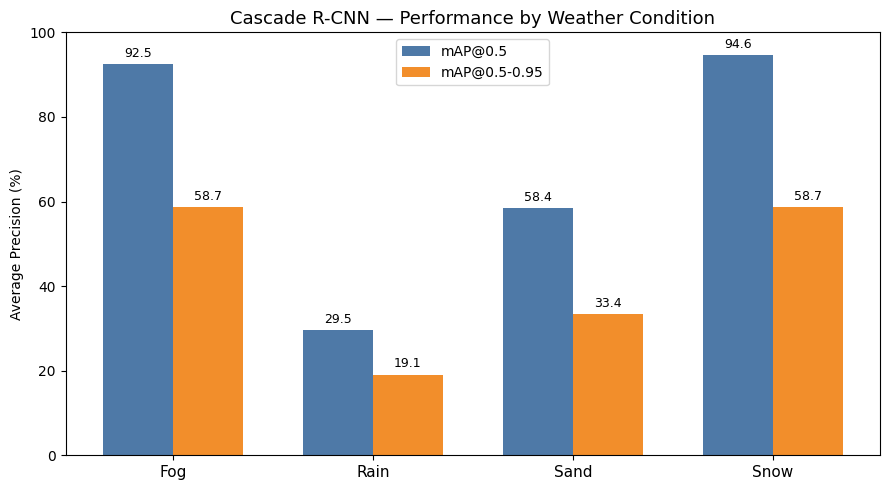

In [80]:
# Plot mAP50 by weather condition
weathers = list(weather_results.keys())
map50s = [weather_results[w]["AP50"] for w in weathers]
maps   = [weather_results[w]["AP"]   for w in weathers]

x = np.arange(len(weathers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, map50s, width, label="mAP@0.5",    color="#4e79a7")
b2 = ax.bar(x + width/2, maps,   width, label="mAP@0.5-0.95", color="#f28e2b")
ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(weathers, fontsize=11)
ax.set_ylabel("Average Precision (%)")
ax.set_title("Cascade R-CNN — Performance by Weather Condition", fontsize=13)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "results_by_weather.png", dpi=150)
plt.show()

## 11. Comparison: Cascade R-CNN vs Faster R-CNN Baseline

In [81]:
# Baseline metrics from Gholinavaz et al. (2025)
# Faster R-CNN on DAWN: Recall ≈ 72%, Precision ≈ 81%
# mAP figures from the paper (approximate, reported as AP50)

baseline = {
    "Model":     "Faster R-CNN (baseline)",
    "Precision": 81.0,
    "Recall":    72.0,
    "mAP50":     None,   # not directly reported — use precision/recall
    # "FPS":       None,
    "Source":    "Gholinavaz et al. (2025)",
}

# Our Cascade R-CNN results — fill after training
# Replace None values with actual results from test_results above
our_results = {
    "Model":     "Cascade R-CNN (ours)",
    "Precision": test_results["bbox"].get("AP", None),   # COCO AP ≈ mAP
    "Recall":    np.nan, # 'AR100' is not a direct key; using np.nan to avoid KeyError
    "mAP50":     test_results["bbox"].get("AP50", None),
    # "FPS":       round(fps, 1),
    "Source":    "This project",
}

comparison_df = pd.DataFrame([baseline, our_results])
comparison_df = comparison_df.set_index("Model")
print(test_results)
print("\n=== Cascade R-CNN vs Faster R-CNN ===")
print(comparison_df.to_string())

OrderedDict({'bbox': {'AP': 36.72619588439217, 'AP50': 63.950471167121314, 'AP75': 38.031079840958846, 'APs': 15.043114671730098, 'APm': 37.57517995542194, 'APl': 64.6837926740969, 'AP-truck': nan, 'AP-person': 38.84065904907346, 'AP-bicycle': 22.04620462046205, 'AP-car': 61.395328108423406, 'AP-motorcycle': 24.622591759609733, 'AP-bus': nan}})

=== Cascade R-CNN vs Faster R-CNN ===
                         Precision  Recall      mAP50                    Source
Model                                                                          
Faster R-CNN (baseline)  81.000000    72.0        NaN  Gholinavaz et al. (2025)
Cascade R-CNN (ours)     36.726196     NaN  63.950471              This project


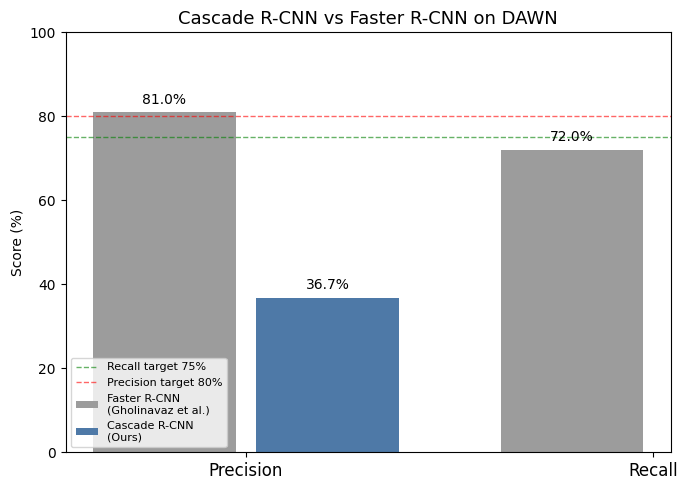

In [82]:
# Bar chart comparison
metrics = ["Precision", "Recall"]
models  = ["Faster R-CNN\n(Gholinavaz et al.)", "Cascade R-CNN\n(Ours)"]

baseline_vals = [baseline["Precision"], baseline["Recall"]]
our_vals      = [our_results["Precision"], our_results["Recall"]]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - 0.2, baseline_vals, 0.35, label=models[0], color="#9c9c9c")
b2 = ax.bar(x + 0.2, our_vals,      0.35, label=models[1], color="#4e79a7")
ax.bar_label(b1, fmt="%.1f%%", padding=4)
ax.bar_label(b2, fmt="%.1f%%", padding=4)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score (%)")
ax.set_title("Cascade R-CNN vs Faster R-CNN on DAWN", fontsize=13)
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(75, color="green", linestyle="--", linewidth=1, alpha=0.6, label="Recall target 75%")
ax.axhline(80, color="red",   linestyle="--", linewidth=1, alpha=0.6, label="Precision target 80%")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_baseline.png", dpi=150)
plt.show()

## 12. Data Fraction Convergence Analysis

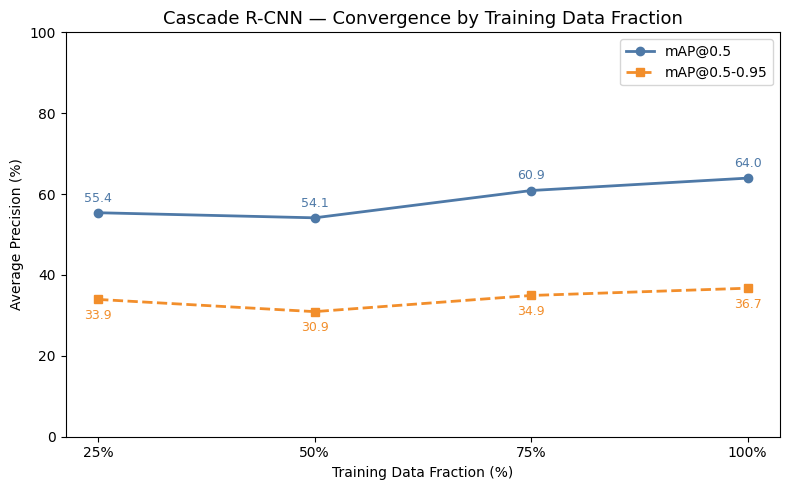

In [83]:
# Add full-dataset result
fraction_results[100] = {
    "map50": test_results["bbox"]["AP50"],
    "map":   test_results["bbox"]["AP"],
    "training_time_min": None,
    "iterations": cfg.SOLVER.MAX_ITER,
}

fracs  = sorted(fraction_results.keys())
map50s = [fraction_results[f]["map50"] for f in fracs]
maps   = [fraction_results[f]["map"]   for f in fracs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fracs, map50s, "o-", label="mAP@0.5",     color="#4e79a7", linewidth=2)
ax.plot(fracs, maps,   "s--", label="mAP@0.5-0.95", color="#f28e2b", linewidth=2)
for f, v1, v2 in zip(fracs, map50s, maps):
    ax.annotate(f"{v1:.1f}", (f, v1), textcoords="offset points", xytext=(0,8),
                ha="center", fontsize=9, color="#4e79a7")
    ax.annotate(f"{v2:.1f}", (f, v2), textcoords="offset points", xytext=(0,-14),
                ha="center", fontsize=9, color="#f28e2b")
ax.set_xlabel("Training Data Fraction (%)")
ax.set_ylabel("Average Precision (%)")
ax.set_title("Cascade R-CNN — Convergence by Training Data Fraction", fontsize=13)
ax.set_xticks(fracs)
ax.set_xticklabels([f"{f}%" for f in fracs])
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "results_fraction_convergence.png", dpi=150)
plt.show()

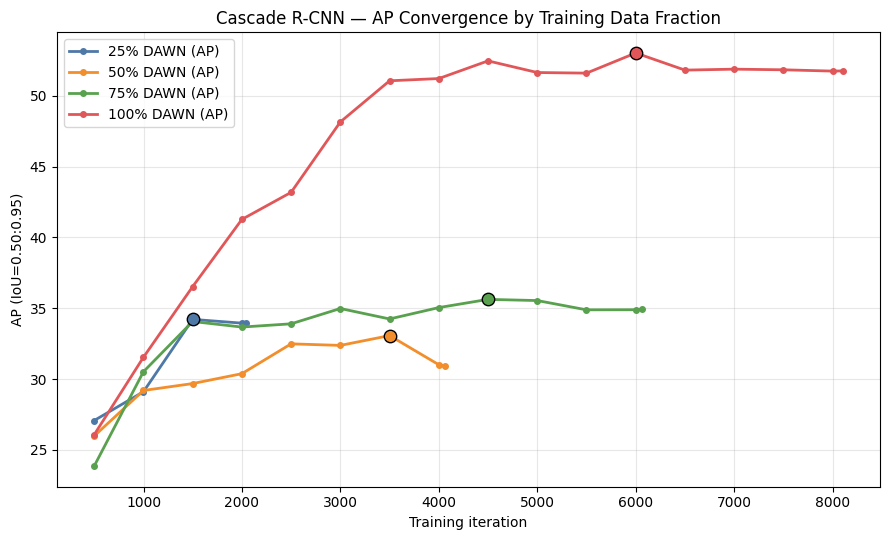

In [84]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

def load_ap_curve(metrics_path):
    iters, ap, ap50 = [], [], []
    with open(metrics_path) as f:
        for line in f:
            row = json.loads(line)
            if "bbox/AP" in row:           # only eval rows have this
                iters.append(row["iteration"])
                ap.append(row["bbox/AP"])
                ap50.append(row["bbox/AP50"])
    return iters, ap, ap50

# Map each run to its output dir — adjust to match your fraction folders
runs = {
    "25% DAWN":  "output_cascade_rcnn/frac25/metrics.json",
    "50% DAWN":  "output_cascade_rcnn/frac50/metrics.json",
    "75% DAWN":  "output_cascade_rcnn/frac75/metrics.json",
    "100% DAWN": "output_cascade_rcnn/metrics.json",
}

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

for (label, path), color in zip(runs.items(), colors):
    if not Path(path).exists():
        print(f"skip {label}: {path} not found")
        continue
    iters, ap, ap50 = load_ap_curve(path)
    ax.plot(iters, ap, "-o", color=color, label=f"{label} (AP)", linewidth=2, markersize=4)
    # mark best point
    best_i = max(range(len(ap)), key=lambda i: ap[i])
    ax.scatter([iters[best_i]], [ap[best_i]], s=80, color=color,
               edgecolor="black", zorder=5)

ax.set_xlabel("Training iteration")
ax.set_ylabel("AP (IoU=0.50:0.95)")
ax.set_title("Cascade R-CNN — AP Convergence by Training Data Fraction")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("output_cascade_rcnn/convergence_comparison.png", dpi=150)
plt.show()

## 13. Qualitative Results — Predictions on Test Images

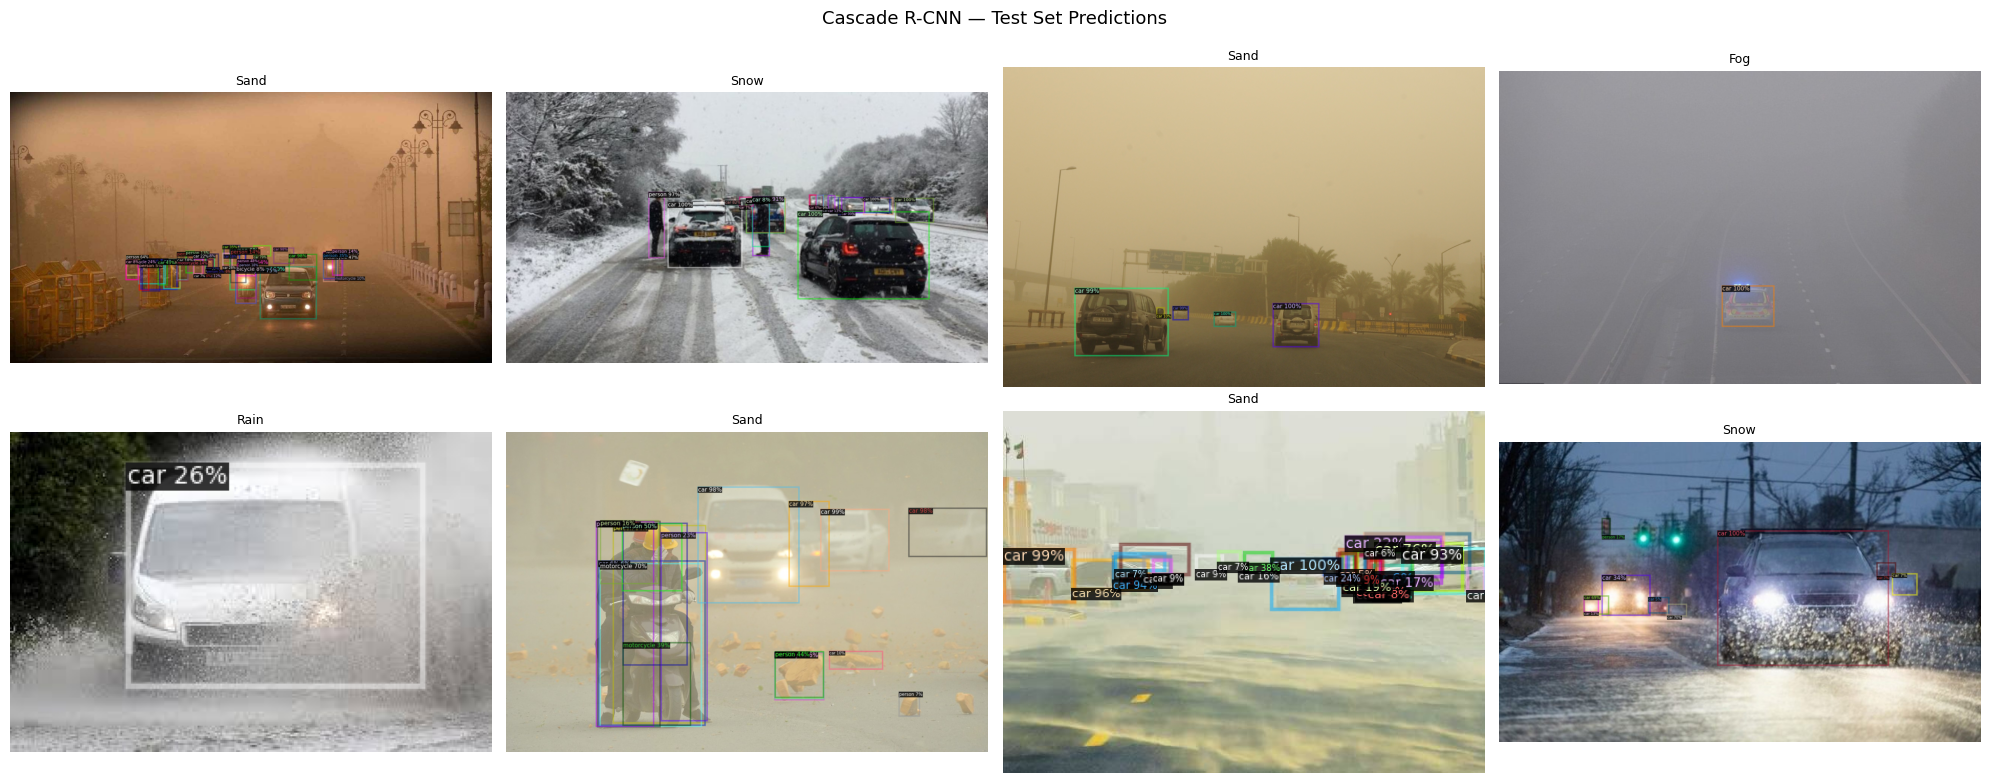

In [85]:
def visualise_predictions(predictor, dataset_name, n=8, conf_thresh=0.5, title=""):
    dicts = DatasetCatalog.get(dataset_name)
    samples = random.sample(dicts, min(n, len(dicts)))
    meta = MetadataCatalog.get(dataset_name)
    meta.thing_classes = YOLO_CLASSES # Changed DAWN_CLASSES to YOLO_CLASSES

    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()

    for ax, d in zip(axes, samples):
        img_bgr = cv2.imread(d["file_name"])
        outputs = predictor(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        v = Visualizer(img_rgb, metadata=meta, scale=1.0)
        vis = v.draw_instance_predictions(outputs["instances"].to("cpu"))
        ax.imshow(vis.get_image())
        weather_tag = next(
            (r["weather"] for r in test_recs if d["file_name"] == r["path"]), ""
        )
        ax.set_title(weather_tag, fontsize=9)
        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "predictions_qualitative.png", dpi=120, bbox_inches="tight")
    plt.show()

visualise_predictions(predictor, "dawn_test", n=8, title="Cascade R-CNN — Test Set Predictions")

## 14. Error Analysis — Misclassified Images


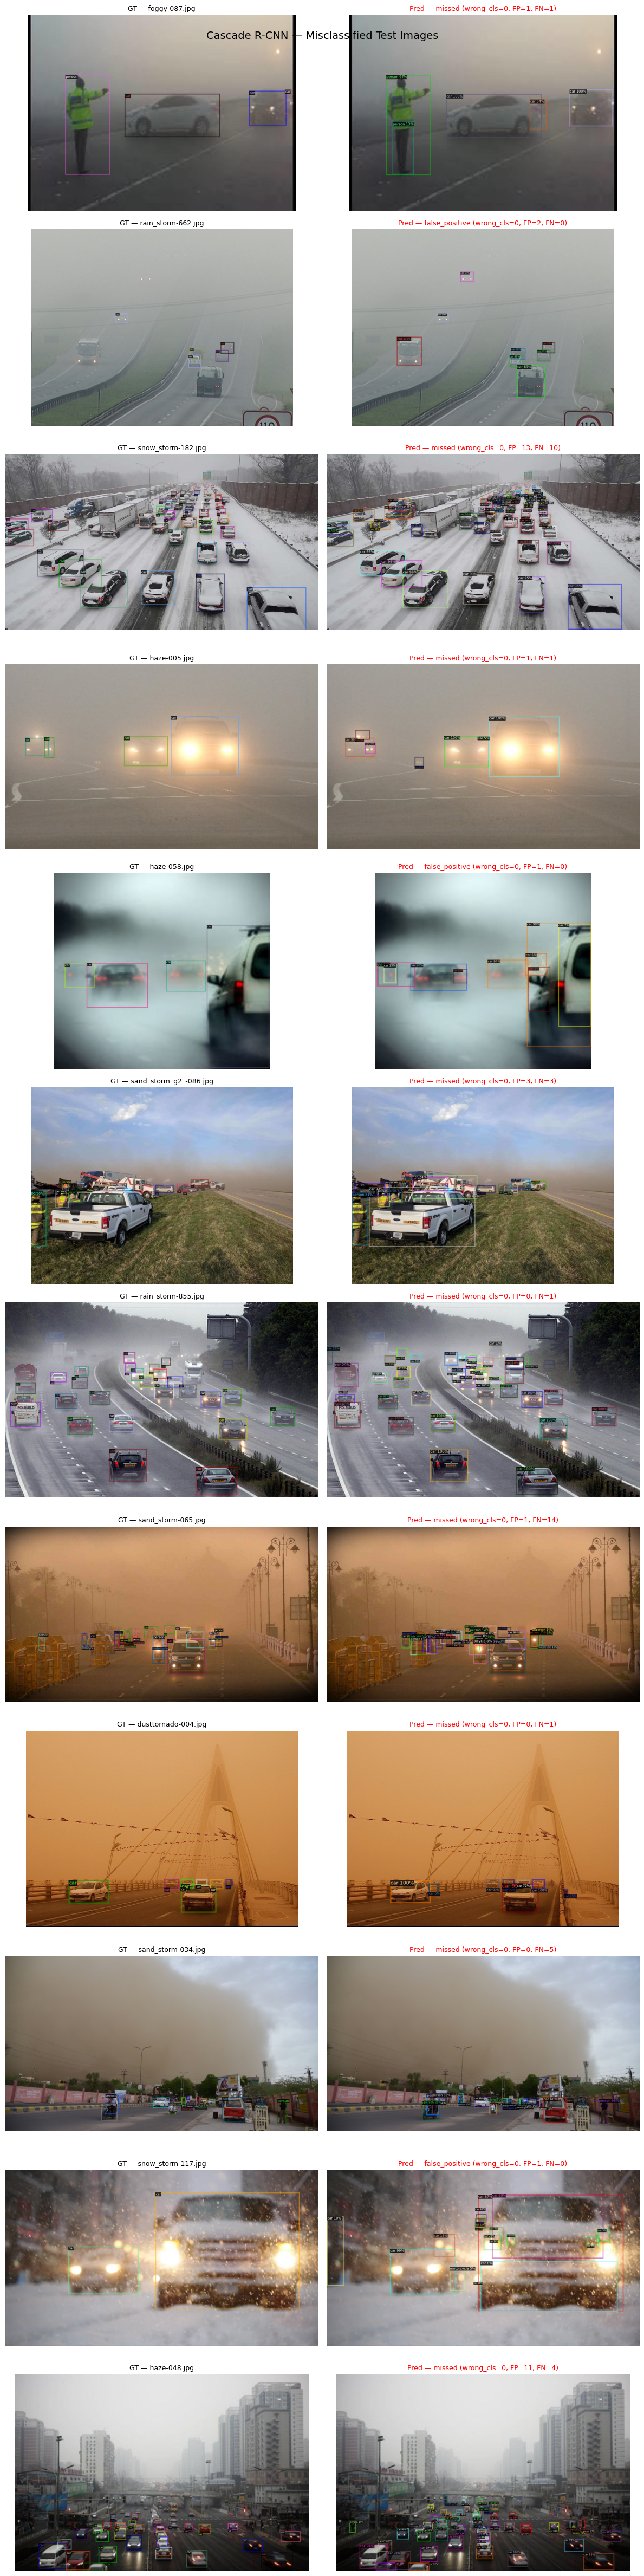

In [86]:
# 14. Error Analysis — Misclassified Images
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.structures import Boxes, pairwise_iou
import torch

def find_misclassified(predictor, dataset_name, iou_thresh=0.5, conf_thresh=0.5, max_images=12):
    """
    Walk the dataset and flag images where predictions disagree with GT.
    Returns a list of (dict, error_type, details) tuples.
    """
    dicts = DatasetCatalog.get(dataset_name)
    errors = []

    for d in dicts:
        img = cv2.imread(d["file_name"])
        if img is None:
            continue

        outputs = predictor(img)["instances"].to("cpu")
        keep = outputs.scores >= conf_thresh
        pred_boxes  = outputs.pred_boxes[keep]
        pred_classes = outputs.pred_classes[keep]

        gt_boxes   = Boxes(torch.tensor([a["bbox"] for a in d["annotations"]], dtype=torch.float32)) \
                     if d["annotations"] else Boxes(torch.zeros((0, 4)))
        gt_classes = torch.tensor([a["category_id"] for a in d["annotations"]], dtype=torch.int64)

        # No preds but GT exists  -> all false negatives
        if len(pred_boxes) == 0 and len(gt_boxes) > 0:
            errors.append((d, "missed_all", f"{len(gt_boxes)} GT objects, 0 detections"))
            continue

        # Preds but no GT -> all false positives
        if len(gt_boxes) == 0 and len(pred_boxes) > 0:
            errors.append((d, "false_positive", f"{len(pred_boxes)} spurious detections"))
            continue

        if len(pred_boxes) == 0 and len(gt_boxes) == 0:
            continue

        ious = pairwise_iou(pred_boxes, gt_boxes)           # [P, G]
        max_iou, matched_gt = ious.max(dim=1)               # best GT for each pred

        wrong_class = 0
        false_pos   = 0
        for i, (iou, gt_idx) in enumerate(zip(max_iou, matched_gt)):
            if iou < iou_thresh:
                false_pos += 1
            elif pred_classes[i] != gt_classes[gt_idx]:
                wrong_class += 1

        # False negatives: GT boxes that no prediction matched with enough IoU
        matched_any = (ious.max(dim=0).values >= iou_thresh) if len(pred_boxes) else torch.zeros(len(gt_boxes), dtype=torch.bool)
        false_neg = int((~matched_any).sum())

        if wrong_class or false_pos or false_neg:
            etype = "wrong_class" if wrong_class else ("missed" if false_neg else "false_positive")
            errors.append((d, etype, f"wrong_cls={wrong_class}, FP={false_pos}, FN={false_neg}"))

        if len(errors) >= max_images:
            break

    return errors


def visualise_misclassified(predictor, dataset_name, title="Misclassified Examples"):
    errors = find_misclassified(predictor, dataset_name)
    if not errors:
        print("No misclassifications found under current thresholds.")
        return

    meta = MetadataCatalog.get(dataset_name)
    meta.thing_classes = YOLO_CLASSES
    cols = 2  # GT | Prediction
    rows = len(errors)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for r, (d, etype, details) in enumerate(errors):
        img_bgr = cv2.imread(d["file_name"])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Left: ground truth
        v_gt = Visualizer(img_rgb, metadata=meta, scale=1.0)
        vis_gt = v_gt.draw_dataset_dict(d)
        axes[r, 0].imshow(vis_gt.get_image())
        axes[r, 0].set_title(f"GT — {Path(d['file_name']).name}", fontsize=9)
        axes[r, 0].axis("off")

        # Right: prediction
        outputs = predictor(img_bgr)
        v_pr = Visualizer(img_rgb, metadata=meta, scale=1.0)
        vis_pr = v_pr.draw_instance_predictions(outputs["instances"].to("cpu"))
        axes[r, 1].imshow(vis_pr.get_image())
        axes[r, 1].set_title(f"Pred — {etype} ({details})", fontsize=9, color="red")
        axes[r, 1].axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "misclassified_examples.png", dpi=120, bbox_inches="tight")
    plt.show()


visualise_misclassified(predictor, "dawn_test", title="Cascade R-CNN — Misclassified Test Images")

## 15. Summary Results Table

In [87]:
# Build a summary table for the report
summary_rows = []

# Baseline (from literature)
summary_rows.append({
    "Model": "Faster R-CNN",
    "Training Data": "100% DAWN",
    "Precision (%)": 81.0,
    "Recall (%)": 72.0,
    "mAP@0.5 (%)": "N/A",
    "mAP@0.5-0.95 (%)": "N/A",
    # "FPS": "N/A",
    "Source": "Gholinavaz et al. 2025",
})

# Our results at each fraction
fraction_results[100] = {
    "map50": test_results["bbox"]["AP50"],
    "map":   test_results["bbox"]["AP"],
    "precision": our_results["Precision"],
    "recall":    our_results["Recall"],
    # "fps":       fps,
}
for frac in sorted(fraction_results.keys()):
    r = fraction_results[frac]
    summary_rows.append({
        "Model": "Cascade R-CNN (ours)",
        "Training Data": f"{frac}% DAWN",
        "Precision (%)":    round(r["precision"], 2) if r.get("precision") else "—",
        "Recall (%)":       round(r["recall"], 2)    if r.get("recall")    else "—",
        "mAP@0.5 (%)":      round(r["map50"], 2)     if r.get("map50")     else "—",
        "mAP@0.5-0.95 (%)": round(r["map"], 2)       if r.get("map")       else "—",
        # "FPS":              round(r["fps"], 1)       if r.get("fps")       else "—",
        "Source": "This project",
    })
# for frac in sorted(fraction_results.keys()):
#     r = fraction_results[frac]
#     if frac == 100:
#         prec = our_results["Precision"]
#         rec  = our_results["Recall"]
#         fps_val = fps
#     else:
#         prec = "—"
#         rec  = "—"
#         fps_val = "—"
    # summary_rows.append({
    #     "Model": "Cascade R-CNN (ours)",
    #     "Training Data": f"{frac}% DAWN",
    #     "Precision (%)": prec,
    #     "Recall (%)": rec,
    #     "mAP@0.5 (%)": round(r["map50"], 2) if r["map50"] else "—",
    #     "mAP@0.5-0.95 (%)": round(r["map"], 2)   if r["map"]   else "—",
    #     "FPS": fps_val if frac == 100 else "—",
    #     "Source": "This project",
    # })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUTPUT_DIR / "summary_results.csv", index=False)
print(f"\nSaved summary to {OUTPUT_DIR / 'summary_results.csv'}")

               Model Training Data  Precision (%) Recall (%) mAP@0.5 (%) mAP@0.5-0.95 (%)                 Source
        Faster R-CNN     100% DAWN          81.00       72.0         N/A              N/A Gholinavaz et al. 2025
Cascade R-CNN (ours)      25% DAWN          33.95          —       55.39            33.95           This project
Cascade R-CNN (ours)      50% DAWN          30.93          —       54.13            30.93           This project
Cascade R-CNN (ours)      75% DAWN          34.93          —       60.88            34.93           This project
Cascade R-CNN (ours)     100% DAWN          36.73        NaN       63.95            36.73           This project

Saved summary to output_cascade_rcnn/summary_results.csv


In [88]:
# Pretty-print weather results
weather_df = pd.DataFrame([
    {
        "Weather": w,
        "mAP@0.5 (%)": round(weather_results[w]["AP50"], 2),
        "mAP@0.5-0.95 (%)": round(weather_results[w]["AP"], 2),
        "AP_small (%)": round(weather_results[w].get("APs", 0), 2),
        "AP_medium (%)": round(weather_results[w].get("APm", 0), 2),
        "AP_large (%)": round(weather_results[w].get("APl", 0), 2),
    }
    for w in weather_results
])
print("\n=== Per-Weather Results ===")
print(weather_df.to_string(index=False))
weather_df.to_csv(OUTPUT_DIR / "weather_results.csv", index=False)


=== Per-Weather Results ===
Weather  mAP@0.5 (%)  mAP@0.5-0.95 (%)  AP_small (%)  AP_medium (%)  AP_large (%)
    Fog        92.48             58.73         16.62          60.47         63.21
   Rain        29.50             19.08         13.48          38.20         74.55
   Sand        58.41             33.43         19.78          39.51         67.41
   Snow        94.62             58.67         16.17          49.06         68.56


## 16. Save Artefacts for Drive

All output files are written to `./output_cascade_rcnn/`.

In [89]:
folder_name = "final2"

shutil.copytree('/content/output_cascade_rcnn', Path('/content/drive/My Drive') / folder_name)

PosixPath('/content/drive/My Drive/final2')

---
## References

- Gholinavaz, S., Saeedi, N., & Samadi Gharehveran, S. (2025). Robustness analysis of YOLO and faster R-CNN for object detection in realistic weather scenarios with noise augmentation. *Scientific Reports*, 15, Article 44888. https://doi.org/10.1038/s41598-025-28737-5
- Shuvoalok. (n.d.). DAWN dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/shuvoalok/dawn-dataset
- Wu, Y., Kirillov, A., Massa, F., Lo, W.-Y., & Girshick, R. (2019). Detectron2. https://github.com/facebookresearch/detectron2
- Cai, Z., & Vasconcelos, N. (2018). Cascade R-CNN: Delving into high quality object detection. *CVPR*.